Use the advertising dataset given in ISLR and analyse the relationship between 'TV advertising' and 'sales' using a simple linear regression model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(filepath_or_buffer = "../input/advertising-dataset/advertising.csv")
print('First 5 data entries:\n',df.head())
print('Shape:',df.shape)
print('describe:\n',df.describe())

First 5 data entries:
       TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
Shape: (200, 4)
describe:
                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


# **Graphical representation:**

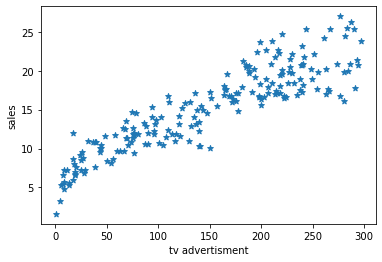

In [2]:
_=plt.scatter(df['TV'],df['Sales'],marker='*')
_=plt.xlabel('tv advertisment')
_=plt.ylabel('sales')
plt.show()

**Conclusion: From the Scatter plot we observe that There is possitive relationship between Tv Advertisment and Sales.**

# **Simple linear regression:**

Here, we are trying to fit simple linear regression model between tv advertisment and sales.we want to know how the tv advertisment affect on sales. the model is 
**sales=beta_0 + beta_1 . tv + error **
where errors are normally distributed.
beta_0 is interscept
beta_1 is the slope

In [3]:
from sklearn import linear_model
import statsmodels.api as sm
x=df['TV']
y=df['Sales']

In [4]:
print("\n model  with statsmodel: \n")

x=sm.add_constant(x)
model=sm.OLS(y,x).fit()
print('Intercept:',model.params[0])
print('Coefficient: ',model.params[1])
print('r square:',model.rsquared)


 model  with statsmodel: 

Intercept: 6.9748214882298925
Coefficient:  0.055464770469558874
r square: 0.8121757029987414


In [5]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     856.2
Date:                Thu, 18 Feb 2021   Prob (F-statistic):           7.93e-74
Time:                        05:47:39   Log-Likelihood:                -448.99
No. Observations:                 200   AIC:                             902.0
Df Residuals:                     198   BIC:                             908.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9748      0.323     21.624      0.000       6.339       7.611
TV             0.0555      0.002     29.260      0.000       0.052       0.059
==============================================================================
Omnibus:                        0.013   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.993   Jarque-Bera (JB):                0.043
Skew:                          -0.018   Prob(JB):                        0.979
Kurtosis:                       2.938   Cond. No.                         338.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

H0: beta0(intercept) is equal to zero. 
H1: beta0(intercept) is not equal to zero.

From the summary output we see that the p value for intercept is 0.000 which is less than 0.05.that means we say that in our model beta0(intercept) is not zero which play significance role in our model.


H0: beta1(slope) is equal to zero. 
H1: beta1(slope) is not equal to zero.

From the summary output we see that the p value for beta1(slope) is 0.000 which is less than 0.05.that means we say that in our model beta1(slope) is not zero which play significance role in our model.

H0: model is significant. 
H1: model is not significant. 

From the summary output we see that the p value for model is  which is 7.93e-74 less than 0.05.that means we say that our model is significant.

In [6]:
print(" model with sklearn: \n") 

regression=linear_model.LinearRegression()
regression.fit(x,y)
print('Intercept:',regression.intercept_)
print('Coefficient:',regression.coef_)
print('r square:',regression.score(x,y))

 model with sklearn: 

Intercept: 6.974821488229896
Coefficient: [0.         0.05546477]
r square: 0.8121757029987414


# **Model for prediction:**
sales = 6.97482 + 0.05546 * tv

Regression line:



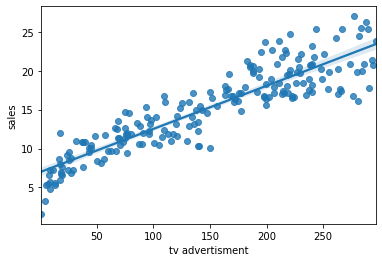

Residual plot:



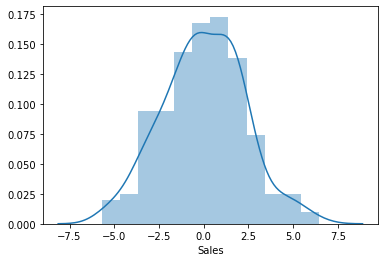

In [7]:
print("Regression line:\n")
import seaborn as sns
_=sns.regplot(x=df['TV'],y=df['Sales'],data=df)
_=plt.xlabel('tv advertisment')
_=plt.ylabel('sales')
plt.show()
print("Residual plot:\n")
y_pred=regression.predict(x)
residual=y_pred-y
_=sns.distplot(residual)
plt.show()

From the residual plot we see that our error follows Normally with mean 0.

## Cross Validation


In [8]:
from sklearn.model_selection import cross_val_score  #Function to compute cross validation score
LRegCV = linear_model.LinearRegression()

scores = cross_val_score(LRegCV, x, y, cv = 5) # Use 5-fold cross validation
scores

array([0.78722103, 0.8390842 , 0.83304785, 0.76034408, 0.79806637])

The average score is taken as the measure of estimator's performance. 

The scores computed by `cross_val_score` is determined by the `score` method of the estimator. For LinearRegression estimator the `score` method computes $R^2$ statistic (Coefficient of determination).

In [9]:
print('Average performance is %.4f.'% np.mean(scores))

Average performance is 0.8036.


Thus, the trained estimator is capable of explaining 79.20% of the variation of the target.

# **Mean Squared Error**

In [10]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer 
mse = make_scorer(mean_squared_error)
cross_val_score(LRegCV, x, y, cv = 5, scoring = mse).mean()

5.345456101166028